In [ ]:
# Marina Browning - 120056058

# Dados de precipitação da estação pluviométrica TUCURUÍ, localizada no estado do Pará, Brasil.
# Fonte: Hidroweb - ANA (Agência Nacional de Águas e Saneamento Básico)
# Código da Estação pluviométrica TUCURUÍ: 349000
# Coordenadas: lat -3.7603 lon -49.6667
# Período contemplado: 10/1995 a 07/2015

#%%
# importações
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# path 
path_precipitacao = r"C:\Users\marin\Projetos\mud-clim-2026.2\02. série precipitação\excel\349000_Chuvas.csv"

In [ ]:
from tabulate import tabulate
# Leitura
# a coluna "TotalAnual" teve que ser removida pois ela começa a ser preenchida a partir da linha 368, o que estava gerando erro na leitrua do csv
df = pd.read_csv(
    path_precipitacao,
    encoding="ISO-8859-1",
    decimal = ",",
    sep=";",
    index_col="Data",
    header = 10,
    usecols=lambda col: col != "TotalAnual"
    )

print(df.columns.tolist())
print(tabulate(df.head(), headers='keys', tablefmt='psql'))

['EstacaoCodigo', 'NivelConsistencia', 'TipoMedicaoChuvas', 'Maxima', 'Total', 'DiaMaxima', 'NumDiasDeChuva', 'MaximaStatus', 'TotalStatus', 'NumDiasDeChuvaStatus', 'TotalAnualStatus', 'Chuva01', 'Chuva02', 'Chuva03', 'Chuva04', 'Chuva05', 'Chuva06', 'Chuva07', 'Chuva08', 'Chuva09', 'Chuva10', 'Chuva11', 'Chuva12', 'Chuva13', 'Chuva14', 'Chuva15', 'Chuva16', 'Chuva17', 'Chuva18', 'Chuva19', 'Chuva20', 'Chuva21', 'Chuva22', 'Chuva23', 'Chuva24', 'Chuva25', 'Chuva26', 'Chuva27', 'Chuva28', 'Chuva29', 'Chuva30', 'Chuva31', 'Chuva01Status', 'Chuva02Status', 'Chuva03Status', 'Chuva04Status', 'Chuva05Status', 'Chuva06Status', 'Chuva07Status', 'Chuva08Status', 'Chuva09Status', 'Chuva10Status', 'Chuva11Status', 'Chuva12Status', 'Chuva13Status', 'Chuva14Status', 'Chuva15Status', 'Chuva16Status', 'Chuva17Status', 'Chuva18Status', 'Chuva19Status', 'Chuva20Status', 'Chuva21Status', 'Chuva22Status', 'Chuva23Status', 'Chuva24Status', 'Chuva25Status', 'Chuva26Status', 'Chuva27Status', 'Chuva28Status'

In [ ]:
'''  foi avaliado que as duplicadas são referentes a mesma data 
    mas com diferentes niveis de consistencia, 
    irei priorizar o tipo 1 que é o que mais tem dados
'''

def filtrar_consistencia_1(df):
    print("Nível de consistência:")
    print(df["NivelConsistencia"].value_counts().sort_index())

    df_filtrado = df[df["NivelConsistencia"] == 1 | df["NivelConsistencia"].isnull()].copy()

    print(f"\nTotal de registros antes do filtro: {len(df)}")
    print(f"Total de registros com consistência 1: {len(df_filtrado)}")

    return df_filtrado

df_consistente = filtrar_consistencia_1(df)

Nível de consistência:
NivelConsistencia
1    500
2    296
Name: count, dtype: int64

Total de registros antes do filtro: 796
Total de registros com consistência 1: 500


In [ ]:
# Converter o índice para datetime
df_consistente.index = pd.to_datetime(
    df_consistente.index,
    format="%d/%m/%Y"
)

# Ordenar cronologicamente
df_consistente = df_consistente.sort_index()

# Criar ano e mês
df_consistente["Ano"] = df_consistente.index.year
df_consistente["Mes"] = df_consistente.index.month

In [ ]:
# identificando as colunas de chuva diaria 
import re

colunas_chuva = [
    col for col in df_consistente.columns
    if re.fullmatch(r"Chuva\d{2}", str(col))
]
print(colunas_chuva)

def preencher_chuva_na(
    df_consistente,
    colunas,
    inicio="1996-07-01",
    fim="1999-02-01",
    random_state=42,
):
    """Preenche a lacuna no formato mensal original do HidroWeb.

    O valor de cada dia é sorteado, com reposição, da distribuição observada
    no mesmo mês em outros anos fora da lacuna. Isso preserva a sazonalidade,
    a frequência de dias secos e os eventos intensos sem interpolação linear.
    """
    inicio = pd.Timestamp(inicio)
    fim = pd.Timestamp(fim)
    if inicio.day != 1 or fim.day != 1 or inicio > fim:
        raise ValueError("inicio e fim devem ser o primeiro dia de um mês.")

    resultado = df_consistente.copy()
    resultado.index = pd.to_datetime(resultado.index)
    resultado.loc[:, colunas] = (
        resultado.loc[:, colunas]
        .replace(r"^\s*$", np.nan, regex=True)
        .replace(["n/a", "N/A", "NaN"], np.nan)
        .apply(pd.to_numeric, errors="coerce")
    )

    meses_lacuna = pd.date_range(inicio, fim, freq="MS")
    indice_original = resultado.index
    meses_novos = meses_lacuna[~meses_lacuna.isin(indice_original)]
    if len(meses_novos) > 0:
        novas_linhas = pd.DataFrame(
            index=meses_novos,
            columns=resultado.columns,
        )
        resultado = pd.concat([resultado, novas_linhas], axis=0)
    resultado = resultado.sort_index()
    resultado.index.name = df_consistente.index.name or "Data"

    valores = (
        df_consistente.loc[:, colunas]
        .replace(r"^\s*$", np.nan, regex=True)
        .replace(["n/a", "N/A", "NaN"], np.nan)
        .apply(pd.to_numeric, errors="coerce")
    )
    valores.index = indice_original
    # Duplicatas do HidroWeb são mantidas no resultado, mas uma única
    # observação por mês é usada para calcular a distribuição histórica.
    valores = valores.groupby(level=0).first()
    fora_lacuna = ~valores.index.isin(meses_lacuna)
    rng = np.random.default_rng(random_state)
    historico = {}

    for mes in range(1, 13):
        linhas_mes = valores.loc[fora_lacuna & (valores.index.month == mes)]
        historico[mes] = {
            coluna: linhas_mes[coluna].dropna().to_numpy()
            for coluna in colunas
        }
        if not any(amostras.size for amostras in historico[mes].values()):
            raise ValueError(f"Não há dados históricos para o mês {mes}.")

        historico[mes]["_mensal"] = (
            linhas_mes[colunas].stack().dropna().to_numpy()
        )

    resultado["DadoSintetico"] = False
    for data in meses_lacuna:
        # Meses que já existem na série original não são alterados.
        if data in indice_original:
            continue

        linha_sintetica = pd.Series(
            index=resultado.columns,
            name=data,
            dtype=object,
        )
        linha_sintetica.loc[:] = np.nan
        linha_sintetica["DadoSintetico"] = True
        dias_no_mes = data.days_in_month
        for dia in range(1, 32):
            coluna = f"Chuva{dia:02d}"
            if coluna not in colunas:
                continue

            if dia > dias_no_mes:
                continue

            amostras = historico[data.month][coluna]
            if amostras.size == 0:
                amostras = historico[data.month]["_mensal"]
            linha_sintetica[coluna] = max(
                0.0, float(rng.choice(amostras))
            )
        resultado = pd.concat(
            [resultado, linha_sintetica.to_frame().T],
            axis=0,
        )

    resultado = resultado.sort_index()

    if "Ano" in resultado.columns:
        resultado["Ano"] = resultado.index.year
    if "Mes" in resultado.columns:
        resultado["Mes"] = resultado.index.month
    return resultado


df_novo = preencher_chuva_na(
    df_consistente,
    colunas_chuva,
    inicio="1996-07-01",
    fim="1999-02-01",
    random_state=42,
)

['Chuva01', 'Chuva02', 'Chuva03', 'Chuva04', 'Chuva05', 'Chuva06', 'Chuva07', 'Chuva08', 'Chuva09', 'Chuva10', 'Chuva11', 'Chuva12', 'Chuva13', 'Chuva14', 'Chuva15', 'Chuva16', 'Chuva17', 'Chuva18', 'Chuva19', 'Chuva20', 'Chuva21', 'Chuva22', 'Chuva23', 'Chuva24', 'Chuva25', 'Chuva26', 'Chuva27', 'Chuva28', 'Chuva29', 'Chuva30', 'Chuva31']


In [ ]:
print("Linhas:", len(df_novo))
print("Datas únicas:", df_novo.index.nunique())
print("Datas duplicadas:", df_novo.index.duplicated().sum())

duplicadas = df_novo.index.duplicated(keep=False)

print(
    df_novo.loc[duplicadas, 
                ["EstacaoCodigo", "NivelConsistencia", "TipoMedicaoChuvas", "Total"]]
    .sort_index()
)

Linhas: 560
Datas únicas: 530
Datas duplicadas: 30
           EstacaoCodigo NivelConsistencia TipoMedicaoChuvas Total
1996-08-01           NaN               NaN               NaN   NaN
1996-08-01           NaN               NaN               NaN   NaN
1996-09-01           NaN               NaN               NaN   NaN
1996-09-01           NaN               NaN               NaN   NaN
1996-10-01           NaN               NaN               NaN   NaN
1996-10-01           NaN               NaN               NaN   NaN
1996-11-01           NaN               NaN               NaN   NaN
1996-11-01           NaN               NaN               NaN   NaN
1996-12-01           NaN               NaN               NaN   NaN
1996-12-01           NaN               NaN               NaN   NaN
1997-01-01           NaN               NaN               NaN   NaN
1997-01-01           NaN               NaN               NaN   NaN
1997-02-01           NaN               NaN               NaN   NaN
1997-02-01 

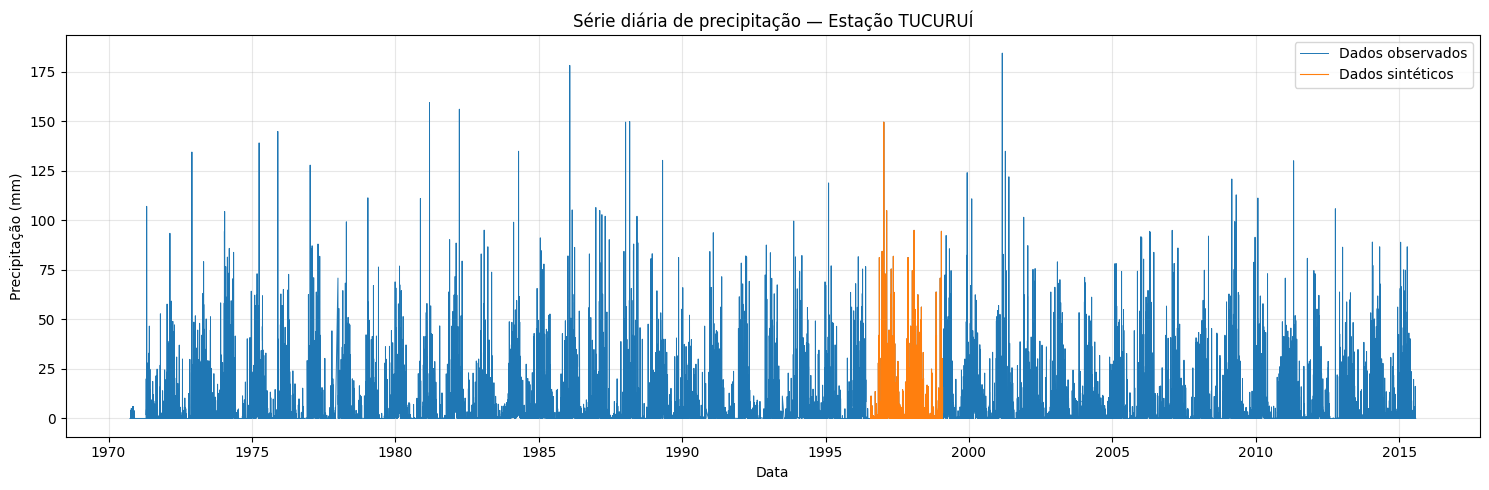

In [ ]:
# Transformando a tabela mensal em série diária.
dias = np.array([int(coluna[-2:]) for coluna in colunas_chuva])
datas_mensais = np.repeat(df_novo.index.to_numpy(), len(colunas_chuva))
datas_diarias = pd.to_datetime(
    {
        "year": pd.DatetimeIndex(datas_mensais).year,
        "month": pd.DatetimeIndex(datas_mensais).month,
        "day": np.tile(dias, len(df_novo)),
    },
    errors="coerce",
)
serie_diaria = pd.DataFrame(
    {
        "precipitacao": pd.to_numeric(
            df_novo[colunas_chuva].to_numpy().ravel(), errors="coerce"
        ),
        "sintetica": np.repeat(
            df_novo["DadoSintetico"].to_numpy(), len(colunas_chuva)
        ),
    },
    index=datas_diarias,
).dropna(subset=["precipitacao"])
serie_diaria = serie_diaria.sort_index()

# Mantém apenas datas válidas e destaca a lacuna preenchida.
serie_diaria = serie_diaria.loc[serie_diaria.index.notna()]
periodo_sintetico = (
    (serie_diaria.index >= pd.Timestamp("1996-07-01"))
    & (serie_diaria.index <= pd.Timestamp("1999-02-28"))
    & serie_diaria["sintetica"]
)

plt.figure(figsize=(15, 5))
plt.plot(
    serie_diaria.index,
    serie_diaria["precipitacao"],
    # color="0.65",
    linewidth=0.7,
    label="Dados observados",
)
plt.plot(
    serie_diaria.index[periodo_sintetico],
    serie_diaria.loc[periodo_sintetico, "precipitacao"],
    # color="tab:orange",
    linewidth=0.8,
    label="Dados sintéticos",
)
# plt.axvspan(
#     pd.Timestamp("1996-07-01"),
#     pd.Timestamp("1999-02-28"),
#     # color="tab:orange",
#     alpha=0.12,
# )
plt.xlabel("Data")
plt.ylabel("Precipitação (mm)")
plt.title("Série diária de precipitação — Estação TUCURUÍ")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
serie_avaliacao = serie_diaria["precipitacao"].astype(float).sort_index()

# Total anual de precipitação
totais_anuais_tendencia = (
    serie_avaliacao
    .resample("YS")
    .sum(min_count=1)
    .dropna()
)

# Anos disponíveis
anos_disponiveis = totais_anuais_tendencia.index.year.to_numpy()

# Número de anos em cada janela
tamanho_janela = 10

# Último ano disponível
ultimo_ano = anos_disponiveis.max()

# Primeiro ano que permite formar uma janela completa de 10 anos
primeiro_ano = anos_disponiveis.min()

# Lista das janelas móveis
janelas = []

for ano_inicial in range(
    primeiro_ano,
    ultimo_ano - tamanho_janela + 2
):
    ano_final = ano_inicial + tamanho_janela - 1

    janelas.append(
        (
            f"{ano_inicial}-{ano_final}",
            ano_inicial,
            ano_final,
        )
    )


# Calculando a tendência de cada janela
resultados_tendencia = []

for nome_janela, ano_inicial, ano_final in janelas:

    dados_janela = totais_anuais_tendencia[
        (totais_anuais_tendencia.index.year >= ano_inicial)
        & (totais_anuais_tendencia.index.year <= ano_final)
    ]

    anos_janela = dados_janela.index.year.to_numpy()
    valores_janela = dados_janela.to_numpy()

    # Só calcula se houver exatamente 10 anos disponíveis
    if len(dados_janela) == tamanho_janela:

        coeficiente = np.polyfit(
            anos_janela,
            valores_janela,
            1
        )

        tendencia = np.polyval(
            coeficiente,
            anos_janela
        )

        resultados_tendencia.append(
            {
                "janela": nome_janela,
                "ano_inicial": ano_inicial,
                "ano_final": ano_final,
                "tendencia_mm_por_ano": coeficiente[0],
            }
        )


# Transformando os resultados em DataFrame
resultados_tendencia = pd.DataFrame(resultados_tendencia)

print("\nTendência em janelas móveis de 10 anos:")
print(resultados_tendencia)


Tendência em janelas móveis de 10 anos:
       janela  ano_inicial  ano_final  tendencia_mm_por_ano
0   1970-1979         1970       1979            183.300606
1   1971-1980         1971       1980             54.163636
2   1972-1981         1972       1981            -67.906061
3   1973-1982         1973       1982            -73.628485
4   1974-1983         1974       1983            -80.676970
5   1975-1984         1975       1984             -8.083030
6   1976-1985         1976       1985             40.448485
7   1977-1986         1977       1986             55.675152
8   1978-1987         1978       1987             62.704848
9   1979-1988         1979       1988             96.484848
10  1980-1989         1980       1989             78.678182
11  1981-1990         1981       1990             14.270909
12  1982-1991         1982       1991            -59.545455
13  1983-1992         1983       1992            -77.953939
14  1984-1993         1984       1993           -124.563030

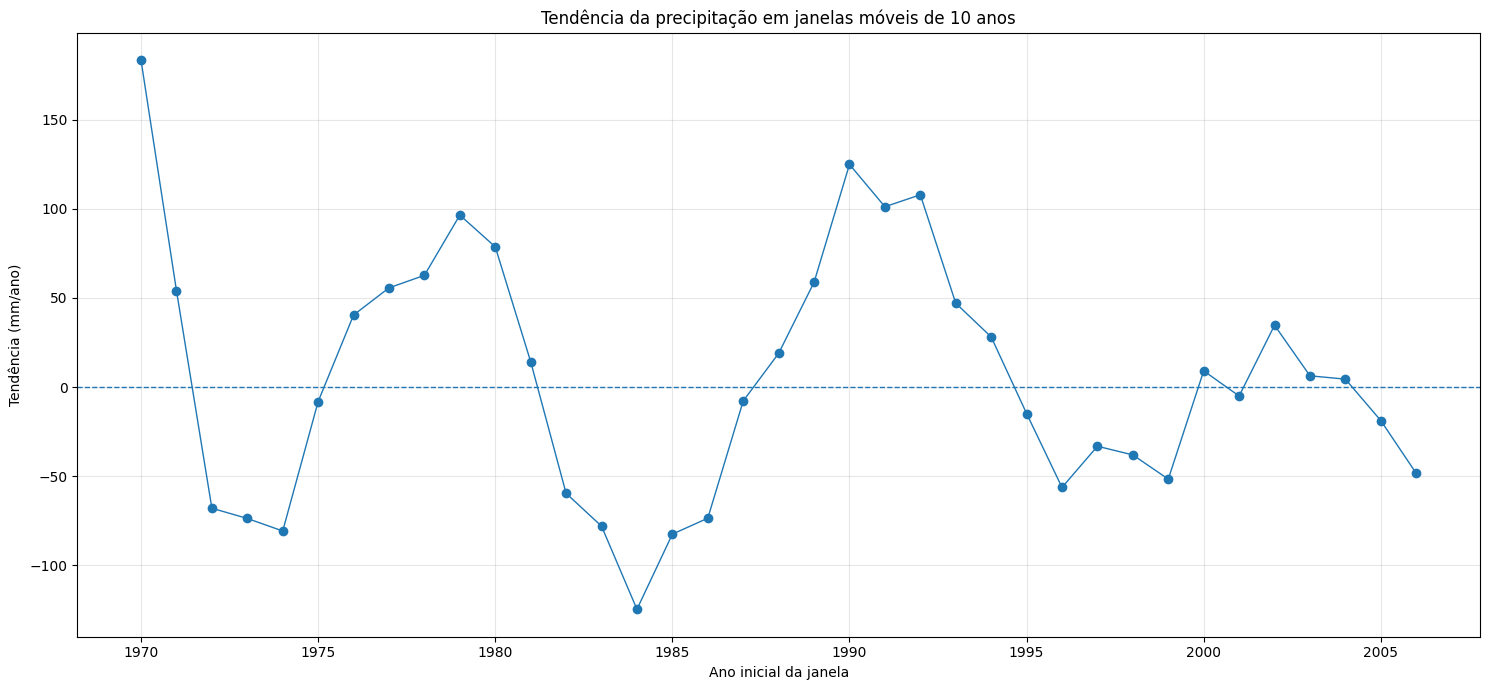

In [ ]:
fig, eixo = plt.subplots(figsize=(15, 7))

eixo.plot(
    resultados_tendencia["ano_inicial"],
    resultados_tendencia["tendencia_mm_por_ano"],
    marker="o",
    linewidth=1,
)

eixo.axhline(
    0,
    linestyle="--",
    linewidth=1,
)

eixo.set_xlabel("Ano inicial da janela")
eixo.set_ylabel("Tendência (mm/ano)")
eixo.set_title(
    "Tendência da precipitação em janelas móveis de 10 anos"
)

eixo.grid(alpha=0.3)

plt.tight_layout()
plt.show()


Extremos por mês:
      q1      q3  limite_superior  quantidade_extremos  maior_valor
mes                                                                
1    0.1  14.600          36.3500                  125        178.1
2    1.0  21.200          51.5000                   65        118.8
3    1.2  19.725          47.5125                   75        184.3
4    0.6  19.600          48.1000                   70        139.0
5    0.0   9.550          23.8750                  152        121.9
6    0.0   1.875           4.6875                  223        102.0
7    0.0   0.400           1.0000                  267         51.3
8    0.0   0.000           0.0000                  261         49.2
9    0.0   0.000           0.0000                  307         36.1
10   0.0   0.100           0.2500                  300        105.8
11   0.0   0.800           2.0000                  245        144.8
12   0.0   5.700          14.2500                  200        124.0

Extremos por ano:
       q1 

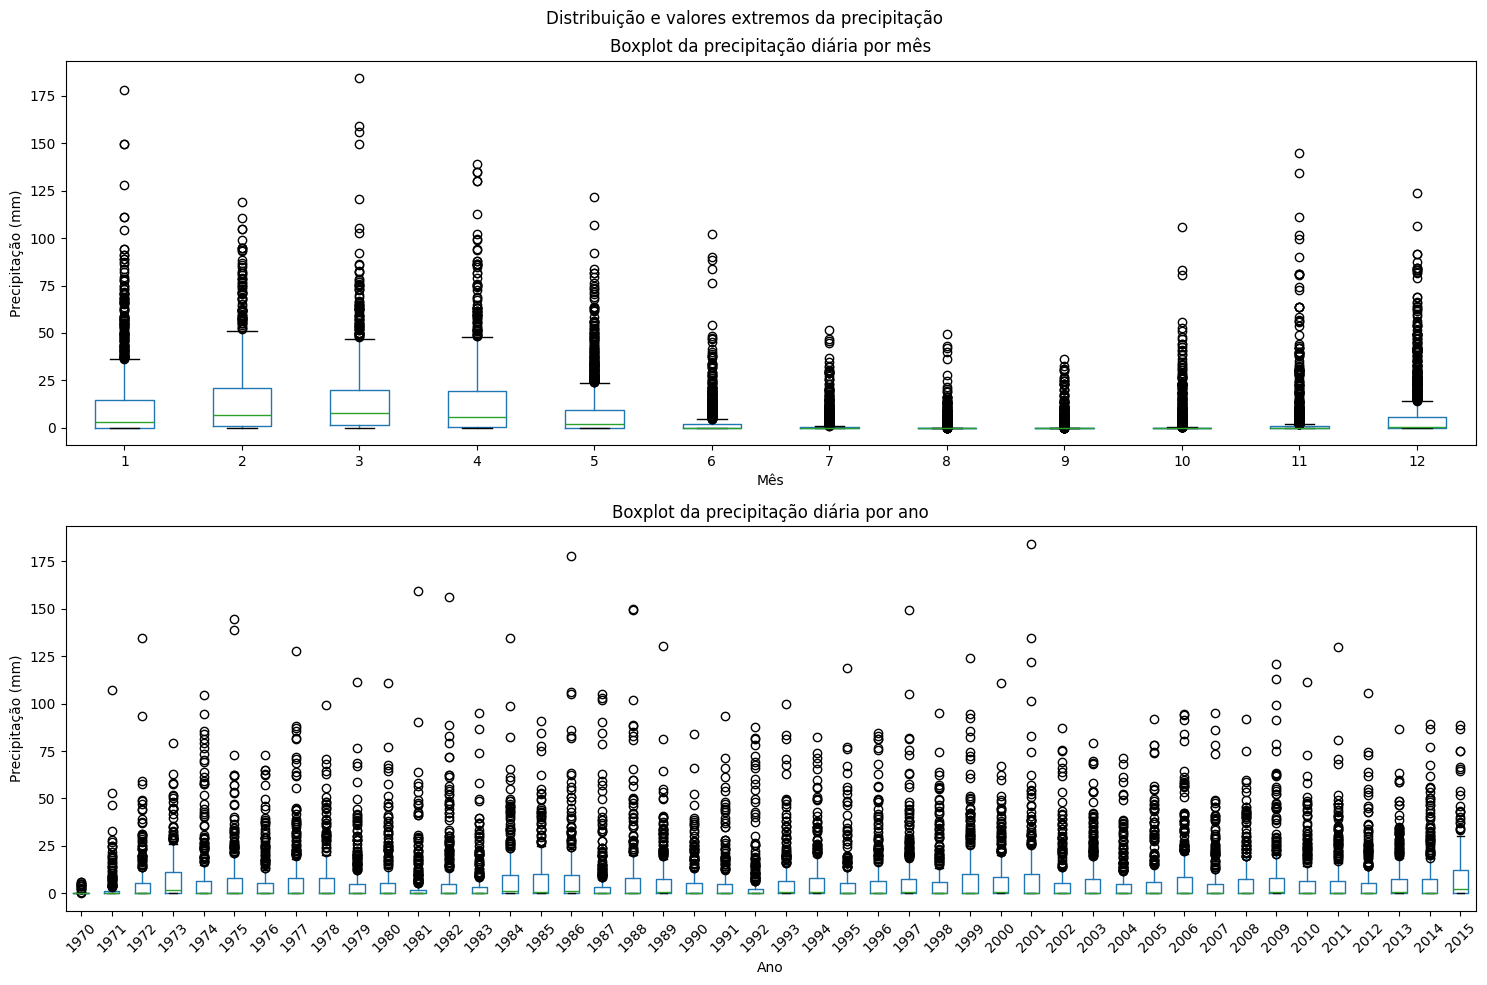

In [ ]:
serie_avaliacao = serie_diaria["precipitacao"].astype(float).sort_index()
dados_boxplot = pd.DataFrame(
    {
        "precipitacao": serie_avaliacao,
        "mes": serie_avaliacao.index.month,
        "ano": serie_avaliacao.index.year,
    },
    index=serie_avaliacao.index,
)

def resumir_extremos_por_grupo(dados, grupo):
    """Calcula limites do IQR e quantidade de extremos por grupo."""
    resumo = []
    for identificador, valores in dados.groupby(grupo)["precipitacao"]:
        q1_grupo = valores.quantile(0.25)
        q3_grupo = valores.quantile(0.75)
        iqr_grupo = q3_grupo - q1_grupo
        limite_superior = q3_grupo + 1.5 * iqr_grupo
        extremos_grupo = valores[valores > limite_superior]
        resumo.append(
            {
                grupo: identificador,
                "q1": q1_grupo,
                "q3": q3_grupo,
                "limite_superior": limite_superior,
                "quantidade_extremos": len(extremos_grupo),
                "maior_valor": valores.max(),
            }
        )
    return pd.DataFrame(resumo).set_index(grupo)


extremos_por_mes = resumir_extremos_por_grupo(dados_boxplot, "mes")
extremos_por_ano = resumir_extremos_por_grupo(dados_boxplot, "ano")

print("\nExtremos por mês:")
print(extremos_por_mes)
print("\nExtremos por ano:")
print(extremos_por_ano)

fig, eixos = plt.subplots(2, 1, figsize=(15, 10))
dados_boxplot.boxplot(
    column="precipitacao",
    by="mes",
    ax=eixos[0],
    grid=False,
    showfliers=True,
)
eixos[0].set_title("Boxplot da precipitação diária por mês")
eixos[0].set_xlabel("Mês")
eixos[0].set_ylabel("Precipitação (mm)")

dados_boxplot.boxplot(
    column="precipitacao",
    by="ano",
    ax=eixos[1],
    grid=False,
    showfliers=True,
)
eixos[1].set_title("Boxplot da precipitação diária por ano")
eixos[1].set_xlabel("Ano")
eixos[1].set_ylabel("Precipitação (mm)")
eixos[1].tick_params(axis="x", rotation=45)

fig.suptitle("Distribuição e valores extremos da precipitação")
plt.tight_layout()
plt.show()


Variabilidade anual:
             total     media  mediana  desvio_padrao  dias_chuvosos  \
1970-01-01    57.7  0.627174     0.00       1.558747             16   
1971-01-01   820.3  2.982909     0.00       9.262981             93   
1972-01-01  2015.9  5.507923     0.35      12.618967            188   
1973-01-01  2883.4  7.899726     1.80      12.520856            218   
1974-01-01  2801.4  7.675068     0.00      16.977694            174   
1975-01-01  2621.4  7.181918     0.30      15.726249            191   
1976-01-01  1946.7  5.793750     0.00      12.265807            151   
1977-01-01  2828.5  8.468563     0.30      17.497993            186   
1978-01-01  2413.3  7.203881     0.20      13.787170            183   
1979-01-01  2060.0  5.754190     0.10      12.817400            180   
1980-01-01  2106.1  5.754372     0.00      13.116906            169   
1981-01-01  1758.8  4.818630     0.00      13.868461            145   
1982-01-01  2639.1  7.230411     0.00      16.787262   

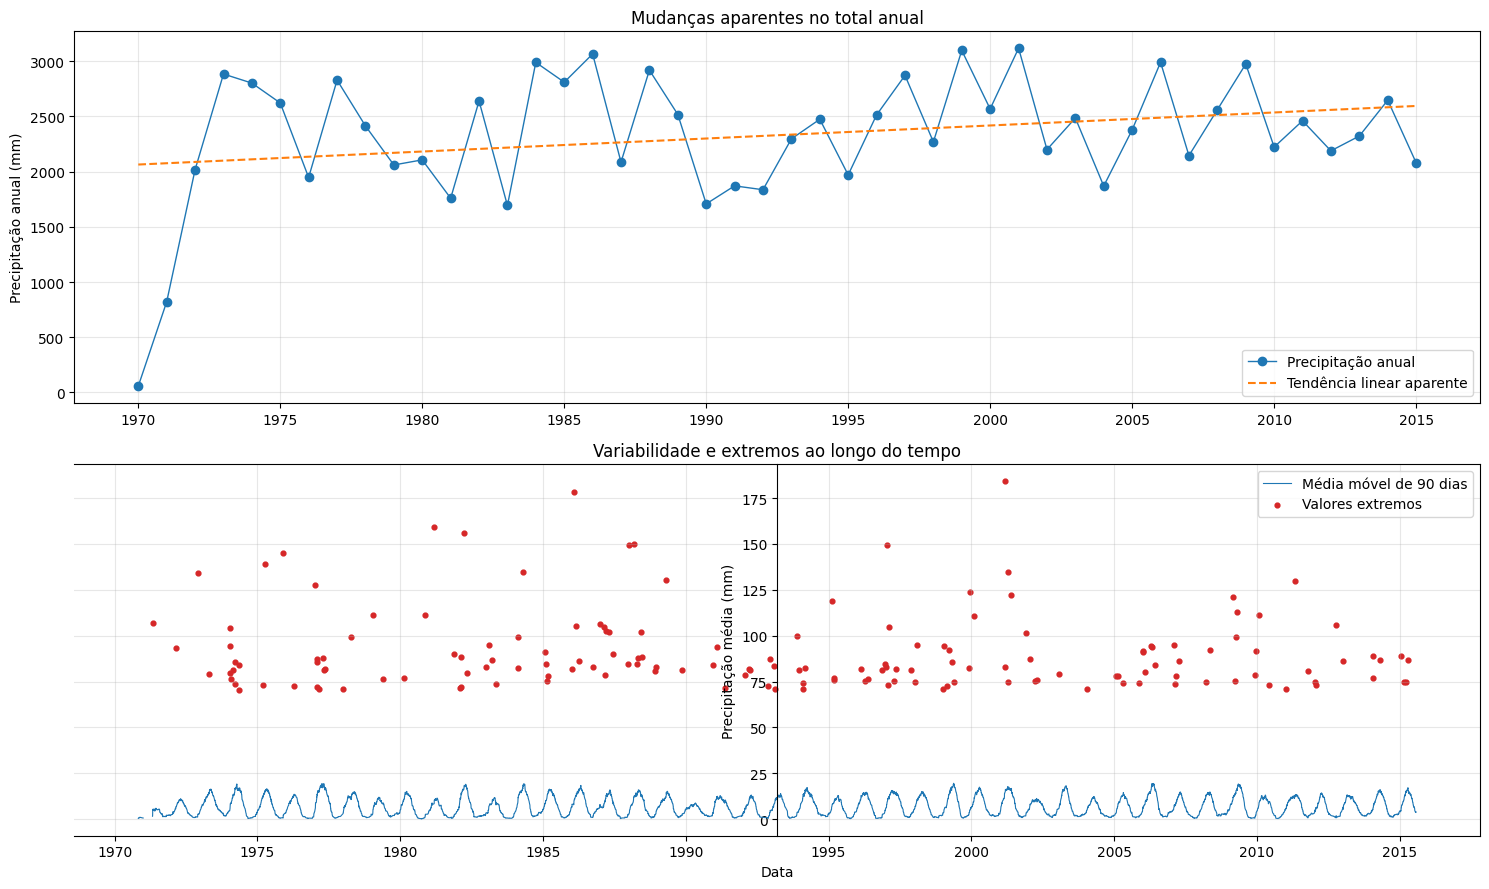

In [ ]:
serie_avaliacao = serie_diaria["precipitacao"].astype(float).sort_index()

# Variabilidade: desvio-padrão e coeficiente de variação por ano.
avaliacao_anual = serie_avaliacao.resample("YS").agg(
    total="sum",
    media="mean",
    mediana="median",
    desvio_padrao="std",
    dias_chuvosos=lambda valores: (valores > 0).sum(),
)
avaliacao_anual["coeficiente_variacao"] = (
    avaliacao_anual["desvio_padrao"] / avaliacao_anual["media"].replace(0, np.nan)
)
print("\nVariabilidade anual:")
print(avaliacao_anual)

# Extremos pelo percentil 99 e pelo limite superior do IQR.
q1 = serie_avaliacao.quantile(0.25)
q3 = serie_avaliacao.quantile(0.75)
iqr = q3 - q1
limite_extremo = q3 + 1.5 * iqr
percentil_99 = serie_avaliacao.quantile(0.99)
extremos = serie_avaliacao[
    serie_avaliacao >= max(limite_extremo, percentil_99)
].sort_values(ascending=False)

print("\nLimites para valores extremos:")
print(f"Q1: {q1:.2f} mm | Q3: {q3:.2f} mm | IQR: {iqr:.2f} mm")
print(f"Limite superior do IQR: {limite_extremo:.2f} mm")
print(f"Percentil 99: {percentil_99:.2f} mm")
print("\nMaiores eventos de precipitação:")
print(extremos.head(20))

# Mudanças aparentes: médias móveis e tendência linear anual.
media_movel_90 = serie_avaliacao.rolling("90D", min_periods=30).mean()
totais_mensais = serie_avaliacao.resample("MS").sum(min_count=1)

anos = avaliacao_anual.index.year.to_numpy()
totais = avaliacao_anual["total"].to_numpy()
validos = ~np.isnan(totais)
coeficiente_tendencia = np.polyfit(anos[validos], totais[validos], 1)[0]
print(
    "\nMudança aparente no total anual: "
    f"{coeficiente_tendencia:.2f} mm/ano"
)
print("\nMédia móvel anual (12 meses):")

fig, eixos = plt.subplots(2, 1, figsize=(15, 9), sharex=False)
eixos[0].plot(
    avaliacao_anual.index,
    avaliacao_anual["total"],
    marker="o",
    linewidth=1,
    label="Precipitação anual",
)
eixos[0].plot(
    avaliacao_anual.index,
    np.polyval(np.polyfit(anos[validos], totais[validos], 1), anos),
    linestyle="--",
    label="Tendência linear aparente",
)

eixos[0].set_ylabel("Precipitação anual (mm)")
eixos[0].set_title("Mudanças aparentes no total anual")
eixos[0].grid(alpha=0.3)
eixos[0].legend()

eixos[1].plot(
    serie_avaliacao.index,
    media_movel_90,
    linewidth=0.8,
    label="Média móvel de 90 dias",
)
eixos[1].scatter(
    extremos.index,
    extremos.values,
    color="tab:red",
    s=12,
    label="Valores extremos",
)

print("\nComparação das tendências por janela temporal:")
eixos[1].spines["left"].set_position(("axes", 0.5))
eixos[1].set_xlabel("Data")
eixos[1].set_ylabel("Precipitação média (mm)")
eixos[1].set_title("Variabilidade e extremos ao longo do tempo")
eixos[1].grid(alpha=0.3)
eixos[1].legend()
plt.tight_layout()
plt.show()


Variabilidade em relação à tendência:
Desvio-padrão dos totais anuais: 580.12 mm
Desvio-padrão dos resíduos: 558.13 mm
Variação explicada pela tendência no período: 530.36 mm
Razão variabilidade/tendência: 1.05
A variabilidade é grande em relação à tendência: as oscilações anuais superam a mudança linear estimada.


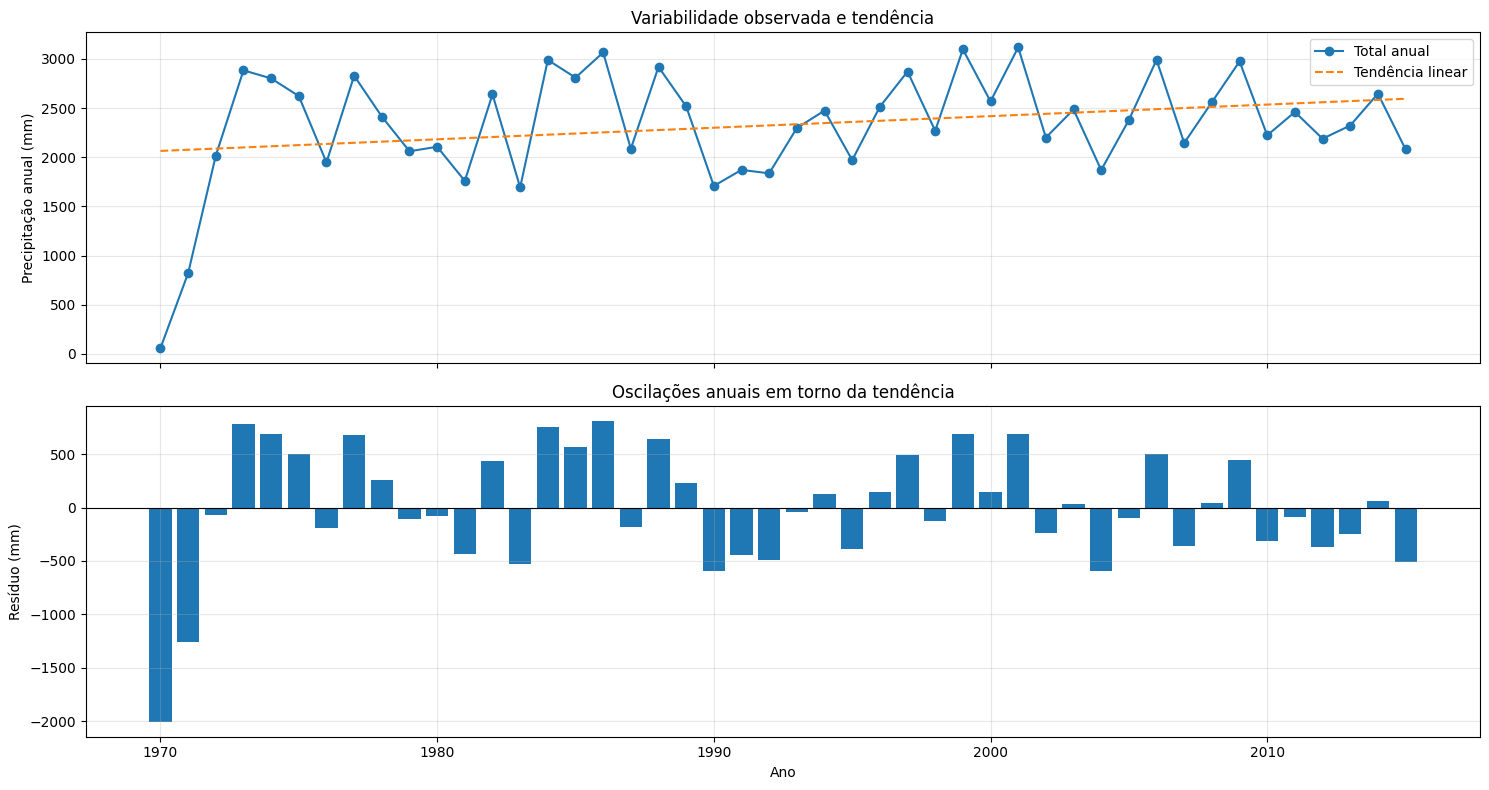

In [ ]:
anos_validos = anos[validos]
totais_validos = totais[validos]
ajuste_tendencia = np.polyval(
    np.polyfit(anos_validos, totais_validos, 1),
    anos_validos,
)
residuos_tendencia = totais_validos - ajuste_tendencia
desvio_padrao_anual = np.std(totais_validos, ddof=1)
desvio_padrao_residuos = np.std(residuos_tendencia, ddof=1)
variacao_explicada_tendencia = abs(
    ajuste_tendencia[-1] - ajuste_tendencia[0]
)
razao_variabilidade_tendencia = (
    desvio_padrao_residuos / variacao_explicada_tendencia
    if variacao_explicada_tendencia > 0
    else np.inf
)

if razao_variabilidade_tendencia > 1:
    interpretacao_variabilidade = (
        "A variabilidade é grande em relação à tendência: "
        "as oscilações anuais superam a mudança linear estimada."
    )
else:
    interpretacao_variabilidade = (
        "A variabilidade é pequena em relação à tendência: "
        "a mudança linear estimada supera as oscilações anuais."
    )

print("\nVariabilidade em relação à tendência:")
print(f"Desvio-padrão dos totais anuais: {desvio_padrao_anual:.2f} mm")
print(f"Desvio-padrão dos resíduos: {desvio_padrao_residuos:.2f} mm")
print(
    "Variação explicada pela tendência no período: "
    f"{variacao_explicada_tendencia:.2f} mm"
)
print(
    "Razão variabilidade/tendência: "
    f"{razao_variabilidade_tendencia:.2f}"
)
print(interpretacao_variabilidade)

fig, eixos = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
eixos[0].plot(
    anos_validos,
    totais_validos,
    marker="o",
    label="Total anual",
)
eixos[0].plot(
    anos_validos,
    ajuste_tendencia,
    linestyle="--",
    label="Tendência linear",
)
eixos[0].set_ylabel("Precipitação anual (mm)")
eixos[0].set_title("Variabilidade observada e tendência")
eixos[0].grid(alpha=0.3)
eixos[0].legend()

eixos[1].axhline(0, color="black", linewidth=0.8)
eixos[1].bar(anos_validos, residuos_tendencia, width=0.8)
eixos[1].set_xlabel("Ano")
eixos[1].set_ylabel("Resíduo (mm)")
eixos[1].set_title("Oscilações anuais em torno da tendência")
eixos[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()


Componente sazonal média por mês:
1     65.463591
2     95.159920
3     94.697895
4     76.499060
5     20.149387
6    -40.267306
7    -69.207365
8    -81.360178
9    -79.147002
10   -61.609621
11   -30.276695
12     8.617772
Name: seasonal, dtype: float64


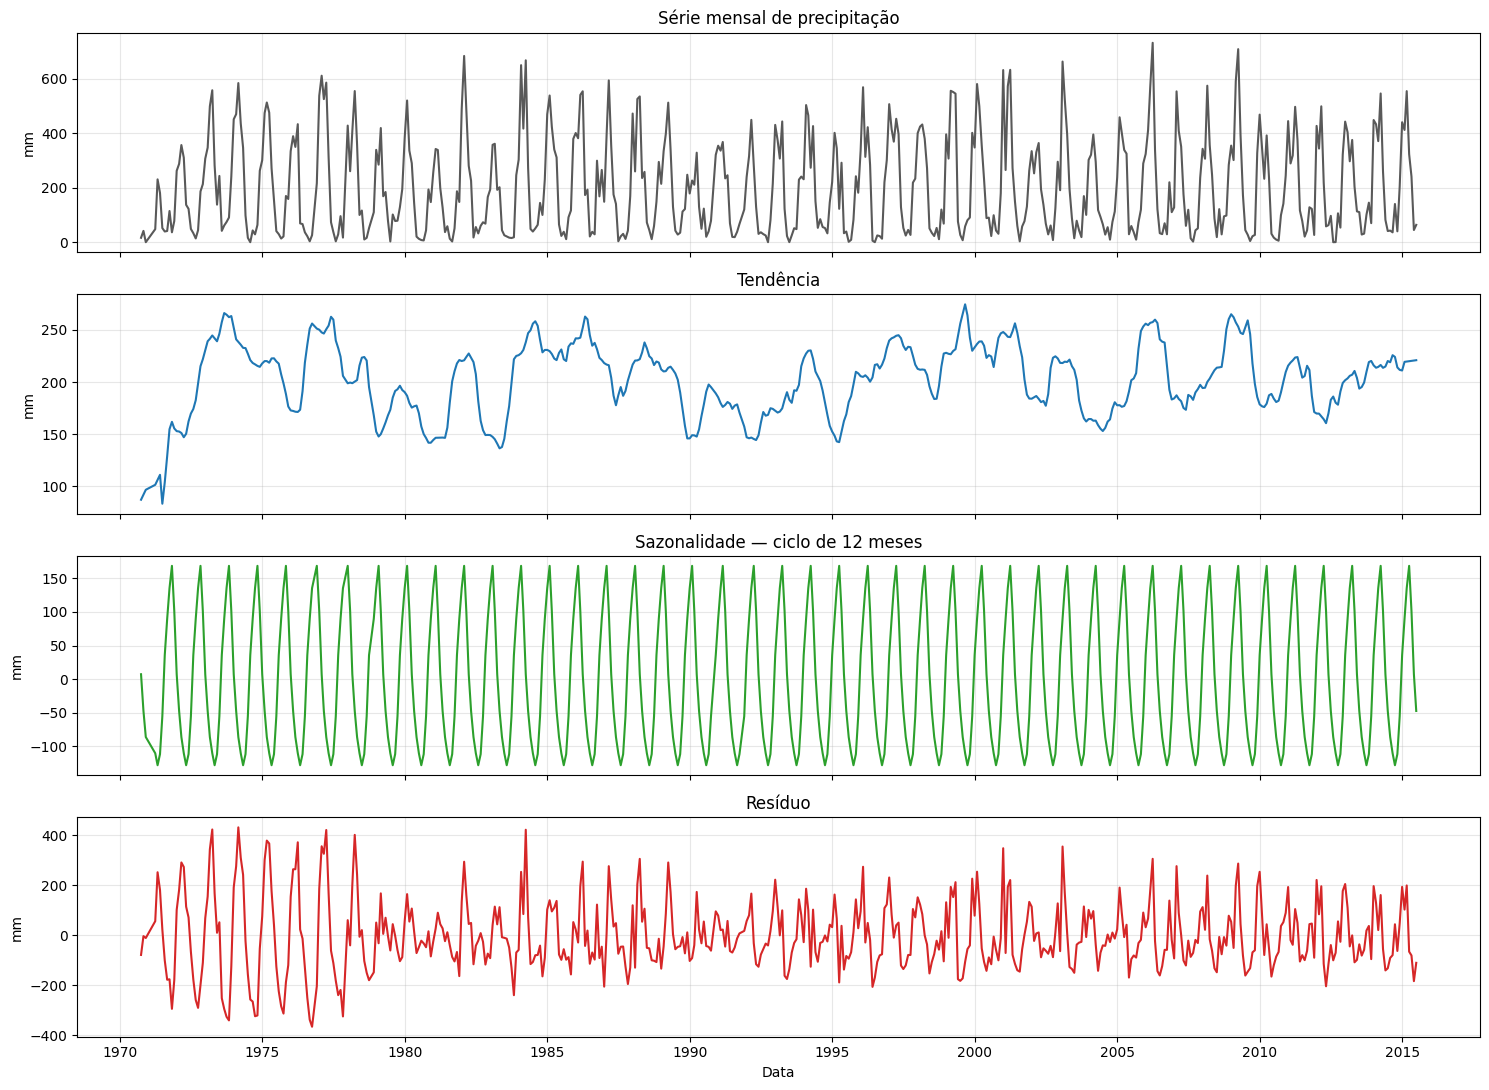

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

serie_mensal = (
    serie_avaliacao.resample("MS")
    .sum(min_count=1)
    .dropna()
)
decomposicao = seasonal_decompose(
    serie_mensal,
    model="additive",
    period=12,
    extrapolate_trend="freq",
)

print("\nComponente sazonal média por mês:")
print(decomposicao.seasonal.groupby(decomposicao.seasonal.index.month).mean())

fig, eixos = plt.subplots(4, 1, figsize=(15, 11), sharex=True)
eixos[0].plot(serie_mensal, color="0.35")
eixos[0].set_title("Série mensal de precipitação")
eixos[1].plot(decomposicao.trend, color="tab:blue")
eixos[1].set_title("Tendência")
eixos[2].plot(decomposicao.seasonal, color="tab:green")
eixos[2].set_title("Sazonalidade — ciclo de 12 meses")
eixos[3].plot(decomposicao.resid, color="tab:red")
eixos[3].set_title("Resíduo")
for eixo in eixos:
    eixo.grid(alpha=0.3)
    eixo.set_ylabel("mm")
eixos[-1].set_xlabel("Data")
plt.tight_layout()
plt.show()

In [ ]:
caminho_saida = (
    r"C:\Users\marin\Projetos\mud-clim-2026.2"
    r"\02. série precipitação\excel\349000_Chuvas_preenchida.csv"
)
df_novo.to_csv(
    caminho_saida,
    sep=";",
    decimal=",",
    encoding="utf-8-sig",
    index_label="Data",
)
print(f"\nSérie preenchida exportada para: {caminho_saida}")


Série preenchida exportada para: C:\Users\marin\Projetos\mud-clim-2026.2\02. série precipitação\excel\349000_Chuvas_preenchida.csv
